# ML Lab 4 — Improving and Comparing Machine Learning Models

**Name:** ____________________  
**Student ID:** ____________________  
**Section:** ____________________  
**GitHub Profile:** ____________________  
**Kaggle Profile:** ____________________  

**Dataset:** `clean_churn.csv`

> This notebook completes Tasks 1–18 from Lab 4. The code is kept simple and beginner-friendly.


## 1. Decision Tree Baseline

**Task 1:** Load the cleaned dataset and create X, y and train/test split.

**Task 2:** Train the Decision Tree baseline and calculate accuracy, precision, recall and F1-score.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv(r"C:\Users\umarc\Desktop\ML-Lab Practice\clean_churn.csv")
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# Check the columns
print(df.columns)
print("Shape:", df.shape)


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
Shape: (7043, 20)


In [23]:
# Target column
target = "Churn"

X = df.drop(columns=[target])
y = df[target]

if y.dtype == "object":
    y = y.map({"Yes": 1, "No": 0})

X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 5634
Testing rows: 1409


In [36]:
# Decision Tree baseline
# max_depth = 5 is used 
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)

print("Decision Tree Results")
print("Accuracy :", round(dt_accuracy, 3))
print("Precision:", round(dt_precision, 3))
print("Recall   :", round(dt_recall, 3))
print("F1-score :", round(dt_f1, 3))


Decision Tree Results
Accuracy : 0.794
Precision: 0.631
Recall   : 0.54
F1-score : 0.582


**Interpretation:** These four scores are our Decision Tree benchmark. F1-score is especially useful when the classes are imbalanced because it considers both precision and recall.


## 2. Random Forest

**Task 3:** Train a Random Forest using the same training data.

**Task 4:** Explain why Random Forest can generalize better than one Decision Tree.


In [41]:
from sklearn.ensemble import RandomForestClassifier

# Created Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# model traning
rf_model.fit(X_train, y_train)

# prediction
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions created.")


Random Forest predictions created.


**Task 4  ANswer:** A Random Forest uses many Decision Trees instead of only one tree. Because many trees work together, the model is usually less dependent on one particular tree and can generalize better to unseen data.


## 3. Model Evaluation

**Task 5:** Calculate the four metrics for Random Forest and plot its confusion matrix.


Random Forest Results
Accuracy : 0.785
Precision: 0.618
Recall   : 0.497
F1-score : 0.551


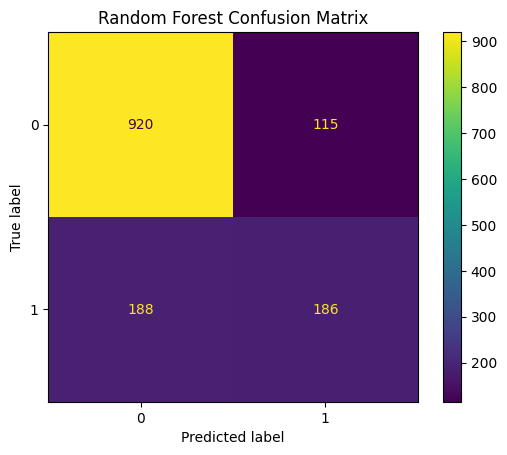

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("Random Forest Results")
print("Accuracy :", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))
print("F1-score :", round(rf_f1, 3))

# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


**Interpretation:** The confusion matrix shows how many customers were correctly and incorrectly classified as churn or not churn. The four numerical metrics give a more complete evaluation than accuracy alone.


## 4. Decision Tree vs Random Forest

**Task 6:** Build one comparison table.

**Task 7:** Decide which model is better and explain the important metric.


In [53]:
# Comparison table
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree": [dt_accuracy, dt_precision, dt_recall, dt_f1],
    "Random Forest": [rf_accuracy, rf_precision, rf_recall, rf_f1]
})

comparison


,Metric,Decision Tree,Random Forest
0,Accuracy,0.794180,0.784954
1,Precision,0.631250,0.617940
2,Recall,0.540107,0.497326
3,F1-score,0.582133,0.551111


**Interpretation:** We compare all four metrics instead of using accuracy only. Since churn data can have class imbalance, recall and F1-score are important. A model that finds more actual churn customers can be more useful, so recall should be considered along with F1-score.


## 5. Cross-Validation




In [54]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
dt_scores = cross_val_score(dt_model, X, y, cv=5, scoring="f1")
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring="f1")

print("Decision Tree F1 scores:", dt_scores)
print("Decision Tree Mean:", round(dt_scores.mean(), 3))
print("Decision Tree Std :", round(dt_scores.std(), 3))

print()

print("Random Forest F1 scores:", rf_scores)
print("Random Forest Mean:", round(rf_scores.mean(), 3))
print("Random Forest Std :", round(rf_scores.std(), 3))


Decision Tree F1 scores: [0.56842105 0.47619048 0.47947455 0.52072968 0.53666147]
Decision Tree Mean: 0.516
Decision Tree Std : 0.035

Random Forest F1 scores: [0.57055215 0.54432348 0.5280236  0.55399061 0.56927711]
Random Forest Mean: 0.553
Random Forest Std : 0.016


**Interpretation:** Cross-validation tests the model on different folds, so it gives a more reliable idea of performance than one train/test split. The mean shows average F1-score, while the standard deviation shows how much the score changes between folds.


## 6. Hyperparameter Tuning



In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "n_estimators": [100, 150],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}


grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parameters,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Cross-Validation F1-score:")
print(round(grid.best_score_, 3))


Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}
Best Cross-Validation F1-score:
0.564


In [56]:
# Best tuned model
tuned_rf = grid.best_estimator_

# Test set prediction
tuned_pred = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred, zero_division=0)
tuned_recall = recall_score(y_test, tuned_pred, zero_division=0)
tuned_f1 = f1_score(y_test, tuned_pred, zero_division=0)

print("Tuned Random Forest Results")
print("Accuracy :", round(tuned_accuracy, 3))
print("Precision:", round(tuned_precision, 3))
print("Recall   :", round(tuned_recall, 3))
print("F1-score :", round(tuned_f1, 3))


Tuned Random Forest Results
Accuracy : 0.799
Precision: 0.657
Recall   : 0.508
F1-score : 0.573


**Interpretation:** GridSearchCV checks a small number of parameter combinations using 5-fold cross-validation. The selected model is the combination that gives the best cross-validated F1-score.


## 7. Final Model Comparison



In [57]:
# Final comparison table
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        tuned_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1,
        tuned_f1
    ]
})

final_comparison.round(3)


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.794,0.631,0.540,0.582
1,Random Forest,0.785,0.618,0.497,0.551
2,Tuned Random Forest,0.799,0.657,0.508,0.573


**Interpretation:** This table gives a fair comparison of all three models using accuracy, precision, recall and F1-score. The final model should not be selected using training performance alone.


## 8. Feature Importance


In [62]:

final_model = tuned_rf

importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

top_features = importance.tail(10)

print("Top important features:")
print(top_features.sort_values(ascending=False))


Top important features:
tenure                            0.178356
TotalCharges                      0.165055
MonthlyCharges                    0.114961
InternetService_Fiber optic       0.075510
PaymentMethod_Electronic check    0.062055
Contract_Two year                 0.061893
OnlineSecurity_Yes                0.039260
Contract_One year                 0.035480
TechSupport_Yes                   0.024658
PaperlessBilling_Yes              0.021338
dtype: float64


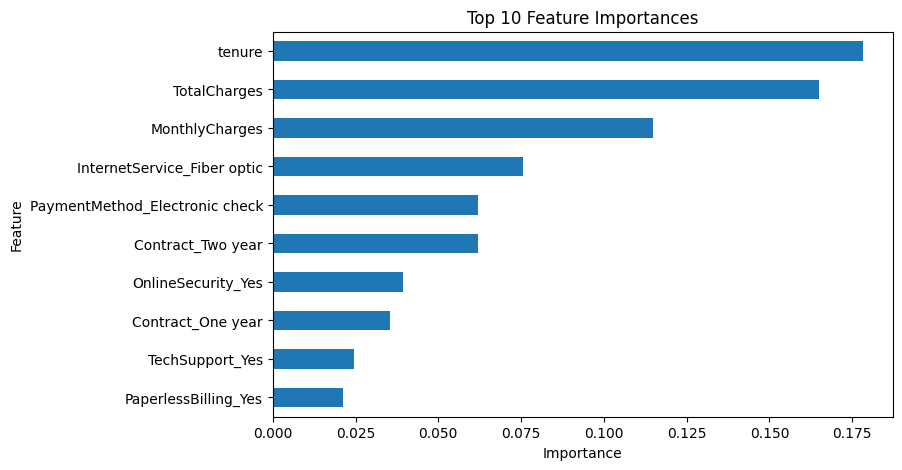

In [63]:
# Plot feature importance
top_features.plot(kind="barh", figsize=(8, 5))

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


**Interpretation:** Feature importance tells us which input features contributed more to the Random Forest's decisions. The top 3–5 features can be compared with the important variables found in earlier EDA and Decision Tree work.


## 9. Final Model Selection

**Task 14:** Select the final model using evidence from the comparison.


In [66]:
# Selecting the model with the highest test F1-score
f1_scores = {
    "Decision Tree": dt_f1,
    "Random Forest": rf_f1,
    "Tuned Random Forest": tuned_f1
}

best_model_name = max(f1_scores, key=f1_scores.get)

print("Final Model:", best_model_name)
print("F1-score:", round(f1_scores[best_model_name], 3))


Final Model: Decision Tree
F1-score: 0.582


**Justification:** I selected the model with the strongest test-set F1-score because F1-score balances precision and recall. This is more appropriate than choosing a model only because it has the highest training score. The final decision should also consider the cross-validation results and the other evaluation metrics.


## 10. Kaggle Prediction / Submission


In [ ]:
final_predictions = final_model.predict(X_test)

possible_id_columns = ["customerID", "CustomerID", "customer_id", "Customer_Id"]

id_column = None
for column in possible_id_columns:
    if column in df.columns:
        id_column = column
        break

if id_column is not None:
    customer_ids = df.loc[X_test.index, id_column]
else:
    customer_ids = X_test.index

submission = pd.DataFrame({
    "customerID": customer_ids,
    "Churn": final_predictions
})

submission["Churn"] = submission["Churn"].map({1: "Yes", 0: "No"})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
submission.head()


submission.csv created successfully.


,customerID,Churn
0,437,No
1,2280,Yes
2,2235,No
3,4460,No
4,3761,No


**Interpretation:** The submission file contains a customer identifier and the model's predicted Churn value. It is saved in the same folder as this notebook as `submission.csv`.


## 11. Conclusion

**Task 17:** Write a short conclusion.

The lab compared a single Decision Tree with a default Random Forest and a tuned Random Forest. Random Forest combines many Decision Trees, which can make the model more stable and improve generalization. Cross-validation gave a more reliable view of F1-score than one train/test split. Hyperparameter tuning was used to find a better Random Forest configuration. The final model was selected using test-set metrics and cross-validation evidence rather than training score alone. A remaining limitation is that class imbalance can still affect churn prediction.


### Task 18 — What I would try next

If I had more time, I would try other algorithms such as Logistic Regression, XGBoost or Gradient Boosting. I would also investigate class-imbalance techniques such as class weights or resampling. I could perform deeper but controlled hyperparameter tuning and compare the models again using F1-score, recall and other suitable metrics.
